# Деревья решений, случайный лес и градиентный бустинг


In [1]:

# Базовые импорты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, load_iris, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, validation_curve
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, log_loss
from sklearn.inspection import permutation_importance

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)

def plot_points(X, y, title="Данные"):
    plt.figure(figsize=(7, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=35, alpha=0.85)
    plt.xlabel("признак 1")
    plt.ylabel("признак 2")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.show()


def plot_decision_boundary(model, X, y, title="Области решений"):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 350),
        np.linspace(y_min, y_max, 350)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolor="k", alpha=0.85)
    plt.xlabel("признак 1")
    plt.ylabel("признак 2")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()


def gini_from_p(p):
    return 1 - p**2 - (1-p)**2


def entropy_from_p(p):
    eps = 1e-12
    p = np.clip(p, eps, 1-eps)
    return -(p*np.log2(p) + (1-p)*np.log2(1-p))


## 1. Интуиция: дерево как набор вопросов

Дерево решений строит прогноз через последовательность простых условий:

```text
признак_1 <= порог?
├── да  → следующий вопрос
└── нет → следующий вопрос
```

Для классификации в листе обычно выбирается самый частый класс.  
Для регрессии в листе обычно берётся среднее значение целевой переменной.

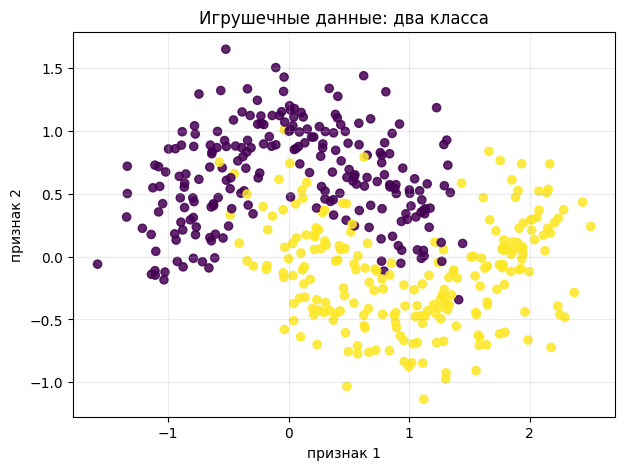

In [2]:

X, y = make_moons(n_samples=450, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
plot_points(X, y, "Игрушечные данные: два класса")


## 2. Жадное построение дерева

Дерево строится сверху вниз. На каждом шаге алгоритм перебирает признаки и пороги и выбирает такой вопрос, который делает дочерние группы более «чистыми».

Упрощённая схема:

1. Берём текущую группу объектов.
2. Проверяем разные вопросы вида `x_j <= t`.
3. Для каждого вопроса считаем, насколько хорошо он разделил данные.
4. Выбираем лучший вопрос.
5. Повторяем процесс отдельно для левой и правой группы.
6. Останавливаемся, когда выполнено условие остановки.

Это жадный алгоритм. Он не ищет глобально лучшее дерево, а выбирает лучший локальный сплит в текущем узле. Поэтому деревья чувствительны к данным и параметрам.

## 3. Критерии качества разбиения

### Классификация

Нам нужно понять, насколько в узле перемешаны классы.

Для бинарной классификации пусть `p` — доля объектов класса 1 в узле.

**Gini:**

$$Gini = 1 - p^2 - (1-p)^2$$

**Entropy:**

$$Entropy = -p\log_2(p) - (1-p)\log_2(1-p)$$

Обе величины равны нулю, когда узел полностью чистый, и максимальны около `p = 0.5`, когда классы перемешаны.

### Регрессия

В регрессии часто минимизируют разброс ответов внутри листа. Самая простая идея — сделать так, чтобы значения в листе были как можно ближе к среднему.

$$MSE = среднее\; значение\; (y_i - \bar y)^2$$

**Как упростить устно:** хорошее разбиение — такое, после которого внутри каждой группы объекты похожи друг на друга по ответу.

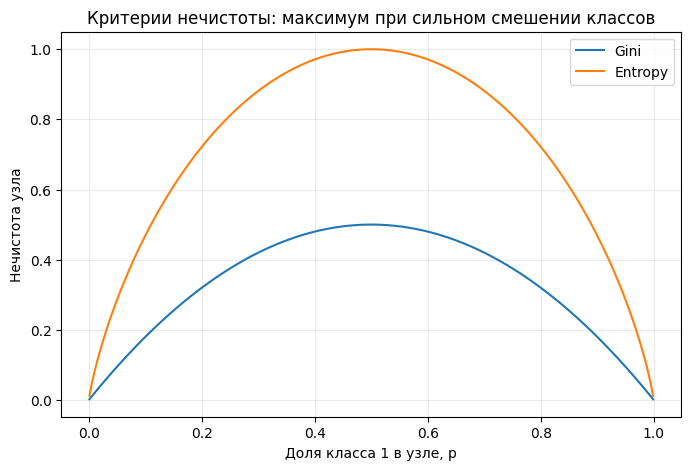

In [3]:

p = np.linspace(0.001, 0.999, 300)
plt.figure(figsize=(8, 5))
plt.plot(p, gini_from_p(p), label="Gini")
plt.plot(p, entropy_from_p(p), label="Entropy")
plt.xlabel("Доля класса 1 в узле, p")
plt.ylabel("Нечистота узла")
plt.title("Критерии нечистоты: максимум при сильном смешении классов")
plt.legend()
plt.grid(alpha=0.25)
plt.show()



## 3.1. Gini, entropy и misclassification error: как объяснить различие

В материалах по деревьям обычно встречаются разные критерии «нечистоты» вершины. Для семинара достаточно такой интерпретации:

- **Gini**: насколько часто мы ошибёмся, если случайно назначим класс пропорционально долям классов в вершине.
- **Entropy**: мера неопределённости; сильнее штрафует смешанные вершины и приходит из теории информации.
- **Misclassification error**: просто доля не-доминирующего класса; интуитивна, но менее чувствительна при выборе разбиений.

На практике `gini` и `entropy` часто дают похожие деревья. Поэтому полезнее обсуждать не «какой критерий всегда лучше», а **как критерий связан с целью сделать дочерние вершины более однородными**.


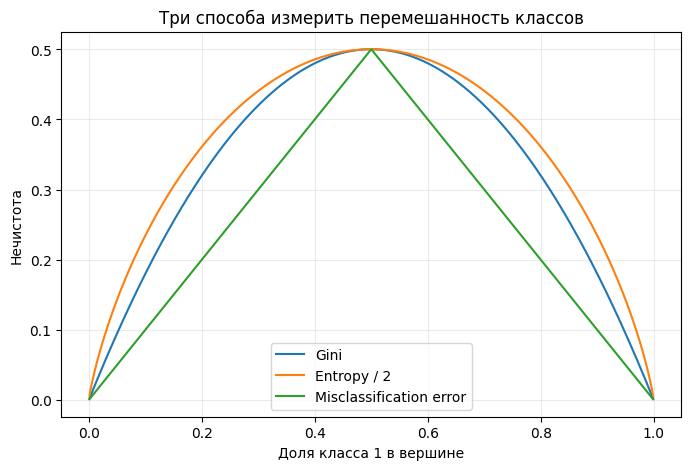

In [4]:

# Сравним три критерия нечистоты для бинарной классификации
p = np.linspace(0.001, 0.999, 400)
gini = 1 - p**2 - (1-p)**2
entropy = -(p*np.log2(p) + (1-p)*np.log2(1-p)) / 2  # делим на 2 только для удобства масштаба
misclass_error = 1 - np.maximum(p, 1-p)

plt.figure(figsize=(8, 5))
plt.plot(p, gini, label='Gini')
plt.plot(p, entropy, label='Entropy / 2')
plt.plot(p, misclass_error, label='Misclassification error')
plt.xlabel('Доля класса 1 в вершине')
plt.ylabel('Нечистота')
plt.title('Три способа измерить перемешанность классов')
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 4. Information gain / уменьшение ошибки

Когда дерево выбирает разбиение, оно сравнивает качество родительского узла и двух дочерних узлов.

Идея:

```text
выигрыш = нечистота_родителя - средняя_нечистота_детей
```

Если после разбиения группы стали чище, выигрыш большой. Если почти ничего не изменилось, разбиение бесполезно.

**Важная деталь:** средняя нечистота детей считается с учётом размера групп. Большая группа влияет на итог сильнее маленькой.

In [5]:

# Небольшой ручной пример: считаем Gini для возможного разбиения
parent = np.array([0, 0, 0, 1, 1, 1, 1, 1])
left = np.array([0, 0, 0, 1])
right = np.array([1, 1, 1, 1])

def gini_labels(labels):
    classes, counts = np.unique(labels, return_counts=True)
    probs = counts / counts.sum()
    return 1 - np.sum(probs ** 2)

parent_gini = gini_labels(parent)
left_gini = gini_labels(left)
right_gini = gini_labels(right)
weighted_children = len(left)/len(parent)*left_gini + len(right)/len(parent)*right_gini
gain = parent_gini - weighted_children

pd.DataFrame({
    "узел": ["родитель", "левый ребенок", "правый ребенок", "среднее детей", "выигрыш"],
    "Gini": [parent_gini, left_gini, right_gini, weighted_children, gain]
})


,узел,Gini
0,родитель,0.46875
1,левый ребенок,0.37500
2,правый ребенок,0.00000
3,среднее детей,0.18750
4,выигрыш,0.28125


## 5. Обучаем дерево и смотрим внутрь

Сейчас обучим неглубокое дерево. Оно не идеально повторяет данные, зато его можно понять визуально.

Train accuracy: 0.917
Test accuracy:  0.919


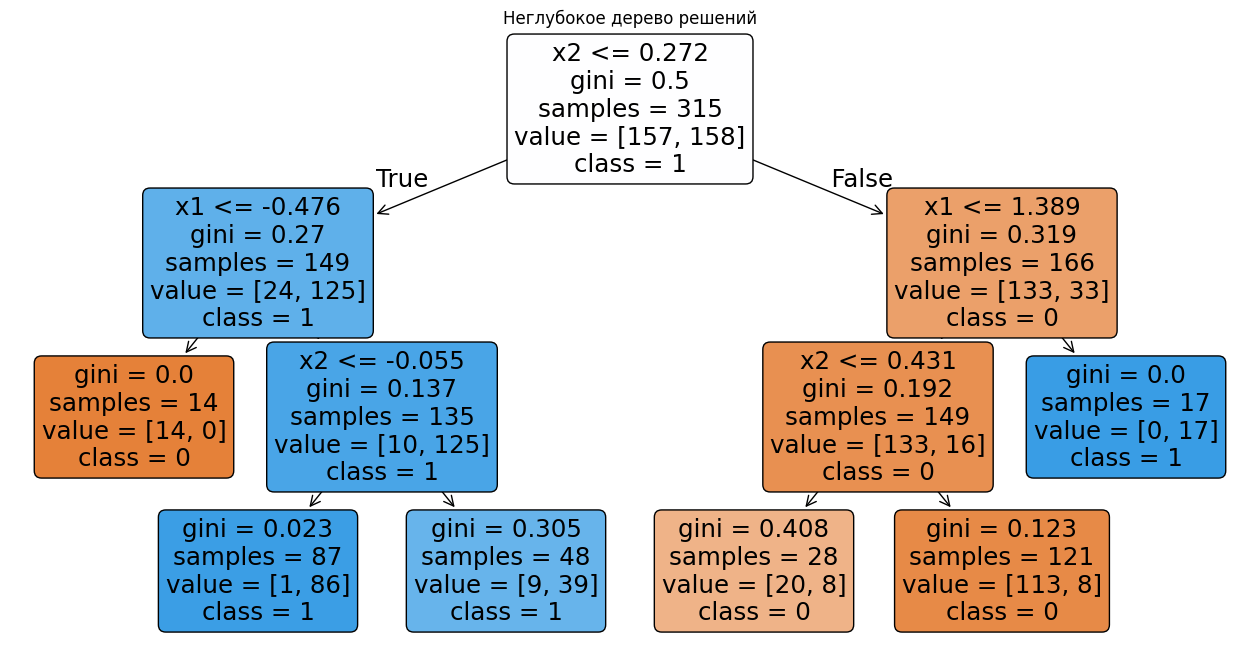

In [6]:

tree_small = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_small.fit(X_train, y_train)

print("Train accuracy:", round(accuracy_score(y_train, tree_small.predict(X_train)), 3))
print("Test accuracy: ", round(accuracy_score(y_test, tree_small.predict(X_test)), 3))

plt.figure(figsize=(16, 8))
plot_tree(tree_small, filled=True, rounded=True, feature_names=["x1", "x2"], class_names=["0", "1"])
plt.title("Неглубокое дерево решений")
plt.show()


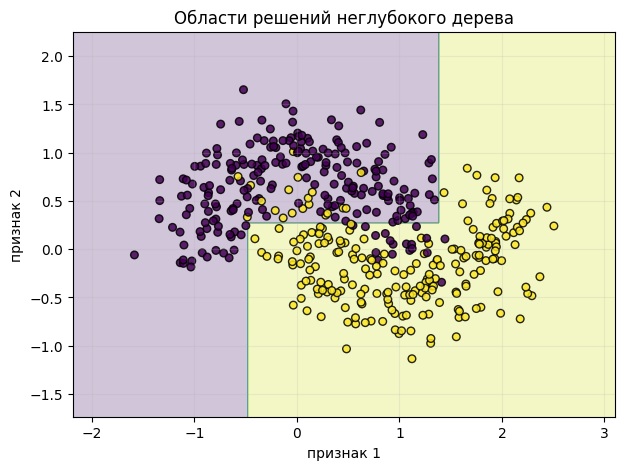

In [7]:

plot_decision_boundary(tree_small, X, y, "Области решений неглубокого дерева")


## 6. Переобучение дерева

Дерево без ограничений может продолжать делить данные до почти идеального запоминания обучающей выборки.

Типичные признаки переобучения:
- качество на train очень высокое;
- качество на test заметно хуже;
- граница решений становится рваной;
- дерево становится слишком глубоким и трудно интерпретируемым.

Основные способы регуляризации:
- `max_depth` — максимальная глубина;
- `min_samples_split` — минимум объектов для разбиения узла;
- `min_samples_leaf` — минимум объектов в листе;
- `max_leaf_nodes` — максимум листьев;
- `ccp_alpha` — post-pruning через cost-complexity pruning.

In [8]:

models = {
    "простое дерево max_depth=3": DecisionTreeClassifier(max_depth=3, random_state=42),
    "глубокое дерево": DecisionTreeClassifier(random_state=42),
    "дерево с min_samples_leaf=20": DecisionTreeClassifier(min_samples_leaf=20, random_state=42),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    rows.append({
        "модель": name,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "test_accuracy": accuracy_score(y_test, model.predict(X_test)),
        "depth": model.get_depth(),
        "leaves": model.get_n_leaves(),
    })

pd.DataFrame(rows).round(3)


,модель,train_accuracy,test_accuracy,depth,leaves
0,простое дерево max_depth=3,0.917,0.919,3,6
1,глубокое дерево,1.000,0.941,11,32
2,дерево с min_samples_leaf=20,0.889,0.844,5,11


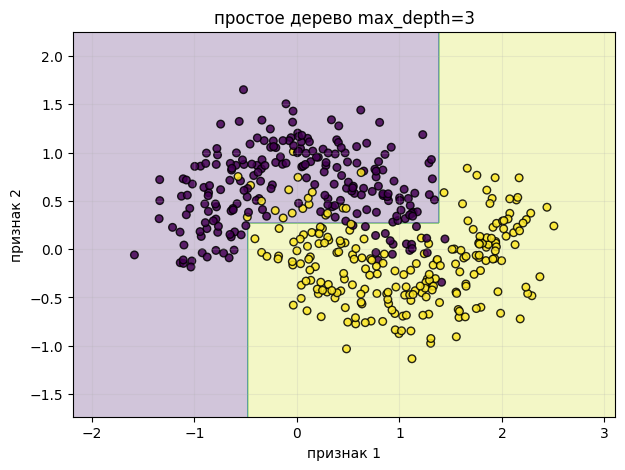

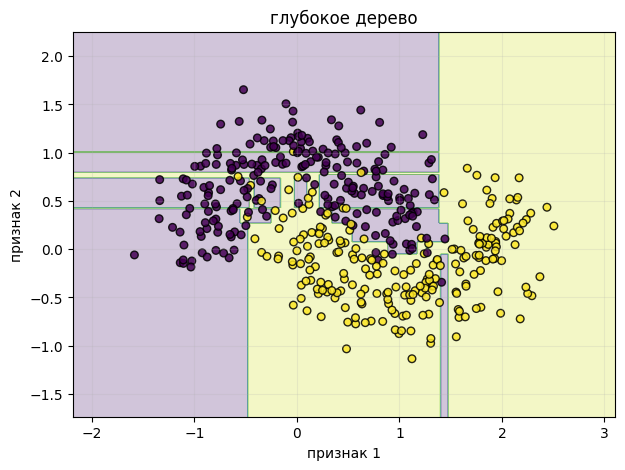

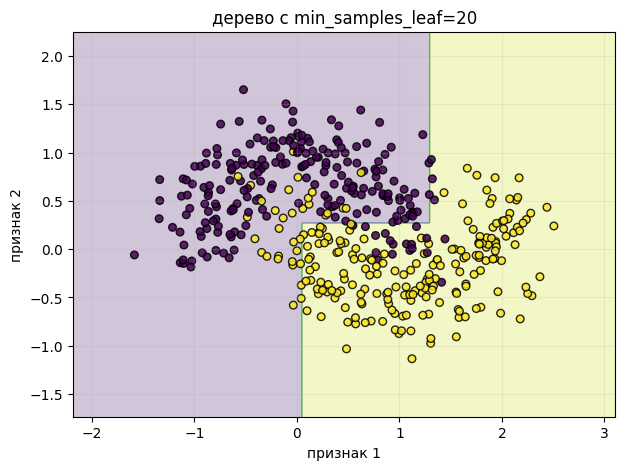

In [9]:

for name, model in models.items():
    plot_decision_boundary(model, X, y, name)



## 6.1. Bias–variance для дерева: почему глубина опасна

Дерево удобно объяснять через баланс смещения и разброса:

- **Маленькая глубина** → модель слишком простая. Она может не увидеть структуру данных. Это высокий bias.
- **Большая глубина** → модель запоминает детали обучающей выборки, включая шум. Это высокий variance.
- **Регуляризация дерева** — это ограничения, которые не дают дереву стать слишком подробным.

Основные ручки регуляризации:

- `max_depth` — максимальная глубина;
- `min_samples_leaf` — минимум объектов в листе;
- `min_samples_split` — минимум объектов для дальнейшего деления;
- `max_leaf_nodes` — максимум листьев;
- `ccp_alpha` — cost-complexity pruning, то есть штраф за сложность дерева.


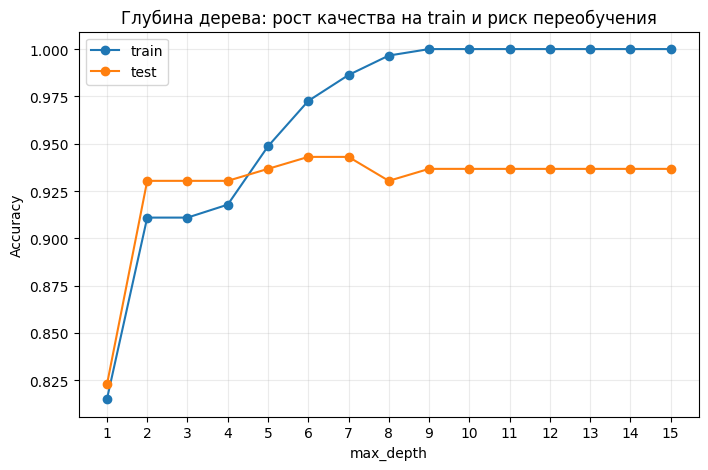

In [10]:

# Validation curve: как глубина дерева влияет на train/test качество
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42, stratify=y)
depths = np.arange(1, 16)
train_scores = []
test_scores = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker='o', label='train')
plt.plot(depths, test_scores, marker='o', label='test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Глубина дерева: рост качества на train и риск переобучения')
plt.xticks(depths)
plt.legend()
plt.grid(alpha=0.25)
plt.show()



### Cost-complexity pruning: идея обрезки дерева

В CART есть идея: сначала можно вырастить достаточно большое дерево, а затем обрезать ветви, которые дают малый выигрыш относительно своей сложности.

Упрощённо оптимизируется компромисс:

$$
\text{ошибка дерева} + \alpha \cdot \text{число листьев}
$$

- маленькое `alpha` почти не штрафует сложность;
- большое `alpha` заставляет дерево быть компактнее;
- слишком большое `alpha` может привести к недообучению.


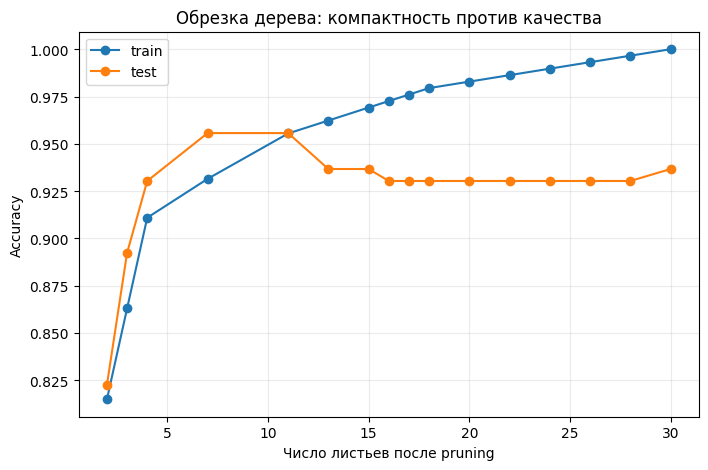

In [11]:

# Демонстрация pruning через ccp_alpha
base_tree = DecisionTreeClassifier(random_state=42)
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]

# Возьмём не все alpha, чтобы график был читаемым
if len(ccp_alphas) > 20:
    idxs = np.linspace(0, len(ccp_alphas)-1, 20).astype(int)
    ccp_alphas_small = ccp_alphas[idxs]
else:
    ccp_alphas_small = ccp_alphas

train_acc, test_acc, leaves = [], [], []
for alpha in ccp_alphas_small:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test)))
    leaves.append(clf.get_n_leaves())

plt.figure(figsize=(8, 5))
plt.plot(leaves, train_acc, marker='o', label='train')
plt.plot(leaves, test_acc, marker='o', label='test')
plt.xlabel('Число листьев после pruning')
plt.ylabel('Accuracy')
plt.title('Обрезка дерева: компактность против качества')
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 7. Подбор гиперпараметров дерева

В реальных задачах глубину и минимальный размер листа лучше не выбирать «на глаз». Используем кросс-валидацию.

Кросс-валидация имитирует ситуацию, где мы несколько раз проверяем модель на данных, которые она не видела при обучении.

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1}
CV accuracy: 0.904
Test accuracy: 0.937


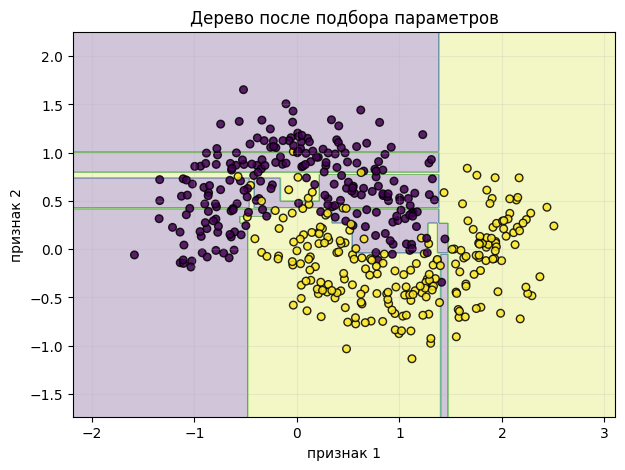

In [12]:

param_grid = {
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_leaf": [1, 5, 10, 20, 40],
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("CV accuracy:", round(grid.best_score_, 3))
print("Test accuracy:", round(accuracy_score(y_test, grid.best_estimator_.predict(X_test)), 3))
plot_decision_boundary(grid.best_estimator_, X, y, "Дерево после подбора параметров")


## 8. Важность признаков

Дерево может оценивать вклад признаков. В `sklearn` есть встроенная `feature_importances_`: она показывает, какие признаки чаще и сильнее уменьшали нечистоту при разбиениях.

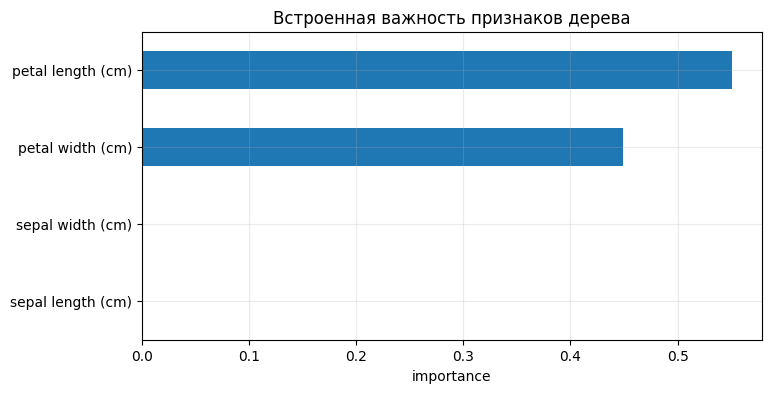

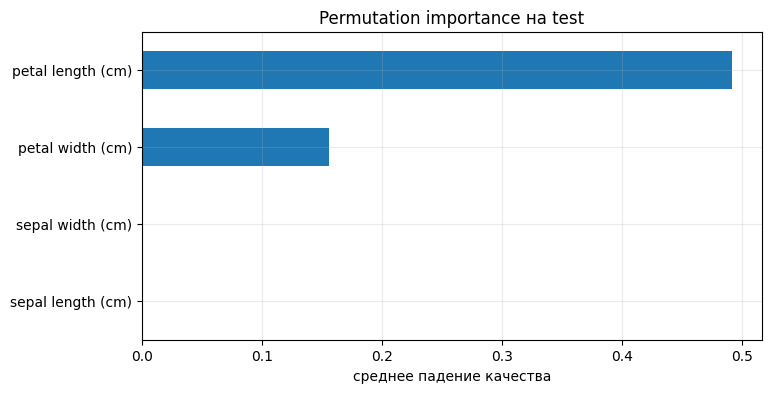

In [13]:

iris = load_iris()
X_i = iris.data
y_i = iris.target
Xtr_i, Xte_i, ytr_i, yte_i = train_test_split(X_i, y_i, test_size=0.3, random_state=42, stratify=y_i)

tree_iris = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_iris.fit(Xtr_i, ytr_i)

imp = pd.Series(tree_iris.feature_importances_, index=iris.feature_names).sort_values()
imp.plot(kind="barh", figsize=(8, 4), title="Встроенная важность признаков дерева")
plt.xlabel("importance")
plt.grid(alpha=0.25)
plt.show()

perm = permutation_importance(tree_iris, Xte_i, yte_i, n_repeats=8, random_state=42)
pd.Series(perm.importances_mean, index=iris.feature_names).sort_values().plot(
    kind="barh", figsize=(8, 4), title="Permutation importance на test"
)
plt.xlabel("среднее падение качества")
plt.grid(alpha=0.25)
plt.show()



## 8.1. Важность признаков: impurity importance vs permutation importance

У деревьев и лесов есть встроенная `feature_importances_`. Она показывает, какие признаки чаще и сильнее уменьшали нечистоту в разбиениях.

Но у этого подхода есть ограничения:

- важность может завышаться для признаков с большим числом возможных порогов;
- коррелированные признаки могут «делить» важность между собой;
- высокая важность не означает причинно-следственную связь.

Более практичная альтернатива — **permutation importance**: перемешиваем один признак и смотрим, насколько падает качество модели. Если качество сильно упало, значит, признак был полезен.


In [14]:

# Сравнение встроенной важности и permutation importance на Iris
rf_iris = RandomForestClassifier(n_estimators=100, random_state=42)
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42, stratify=iris.target
)
rf_iris.fit(X_iris_train, y_iris_train)
perm = permutation_importance(rf_iris, X_iris_test, y_iris_test, n_repeats=8, random_state=42)

importance_df = pd.DataFrame({
    'feature': iris.feature_names,
    'impurity_importance': rf_iris.feature_importances_,
    'permutation_importance': perm.importances_mean
}).sort_values('permutation_importance', ascending=False)

importance_df


,feature,impurity_importance,permutation_importance
3,petal width (cm),0.454892,0.166667
2,petal length (cm),0.400227,0.102778
1,sepal width (cm),0.024273,-0.002778
0,sepal length (cm),0.120608,-0.019444


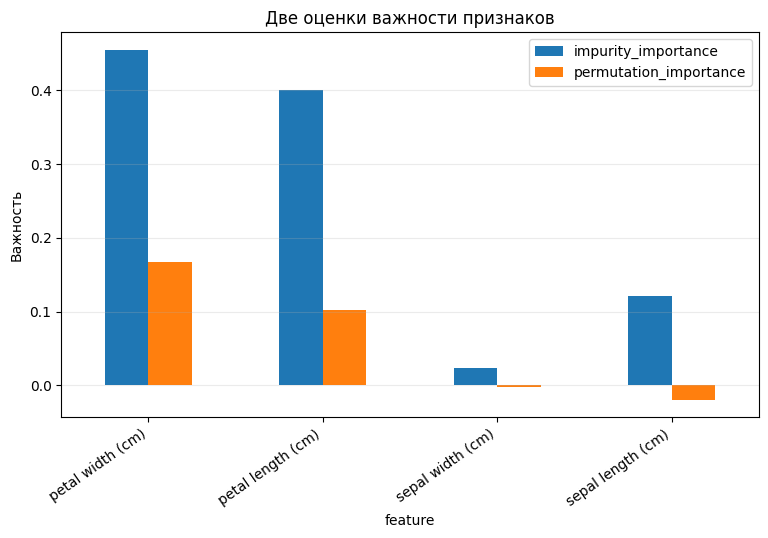

In [15]:

importance_df.set_index('feature')[['impurity_importance', 'permutation_importance']].plot(kind='bar', figsize=(9, 5))
plt.title('Две оценки важности признаков')
plt.ylabel('Важность')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.show()


## 9. Дерево для регрессии

Для регрессии дерево делает кусочно-постоянный прогноз: в каждом листе предсказывает среднее значение `y` по объектам этого листа.

Это удобно показать на одномерном примере: дерево не строит гладкую линию, а собирает ступеньки.

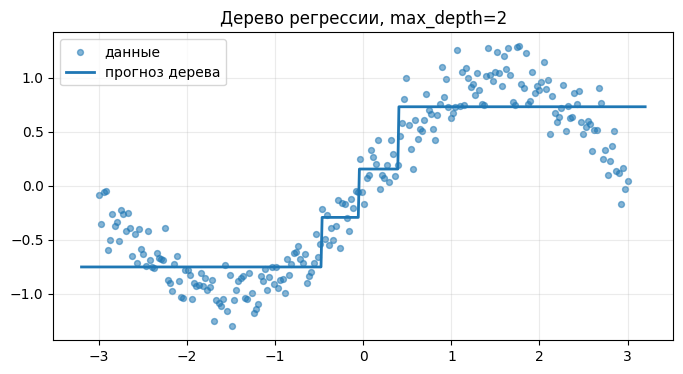

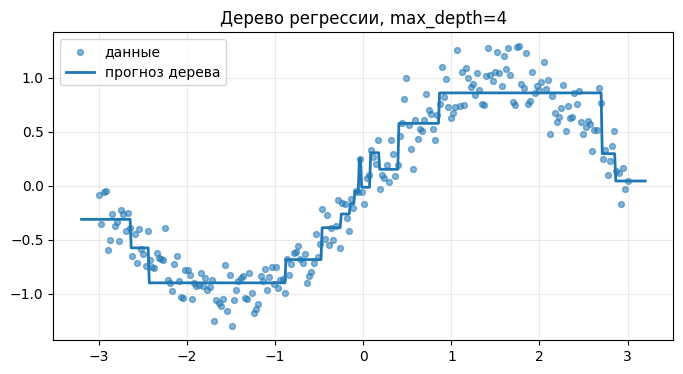

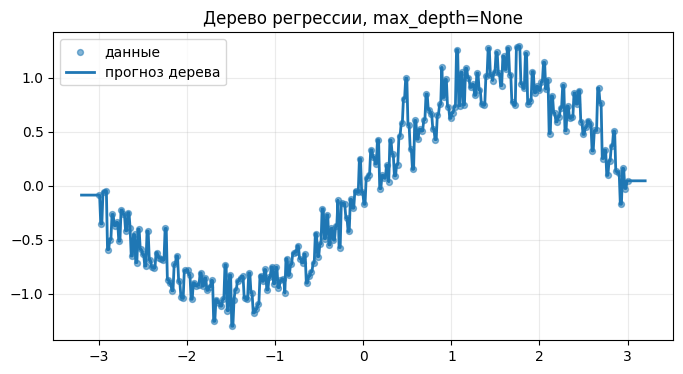

In [16]:

rng = np.random.default_rng(42)
X_reg = np.linspace(-3, 3, 240).reshape(-1, 1)
y_reg = np.sin(X_reg[:, 0]) + rng.normal(0, 0.18, size=X_reg.shape[0])

for depth in [2, 4, None]:
    reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg_tree.fit(X_reg, y_reg)
    xs = np.linspace(-3.2, 3.2, 500).reshape(-1, 1)
    plt.figure(figsize=(8, 4))
    plt.scatter(X_reg[:, 0], y_reg, s=18, alpha=0.55, label="данные")
    plt.plot(xs[:, 0], reg_tree.predict(xs), linewidth=2, label="прогноз дерева")
    plt.title(f"Дерево регрессии, max_depth={depth}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## 10. Ансамбли: зачем много деревьев

Одно дерево понятно, но нестабильно: небольшое изменение данных может заметно изменить структуру дерева. Ансамбли уменьшают этот недостаток.

### Bagging

Bagging строит много моделей на разных bootstrap-выборках и усредняет их ответы. Bootstrap — это выборка с возвращением из исходных данных.

### Random Forest

Случайный лес — это bagging над деревьями плюс дополнительная случайность: в каждом узле дерево рассматривает не все признаки, а случайное подмножество. Это делает деревья менее похожими друг на друга.

### Boosting

Boosting строит модели последовательно: каждая следующая модель исправляет ошибки предыдущих. В градиентном бустинге новые деревья приближают антиградиент функции потерь, но для первого объяснения достаточно идеи «каждое следующее дерево исправляет остатки».

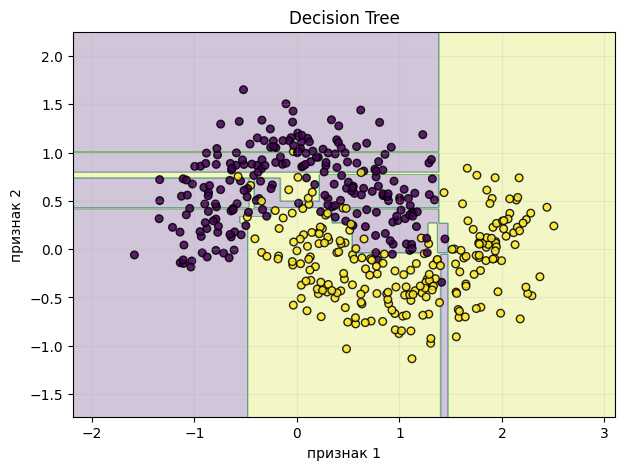

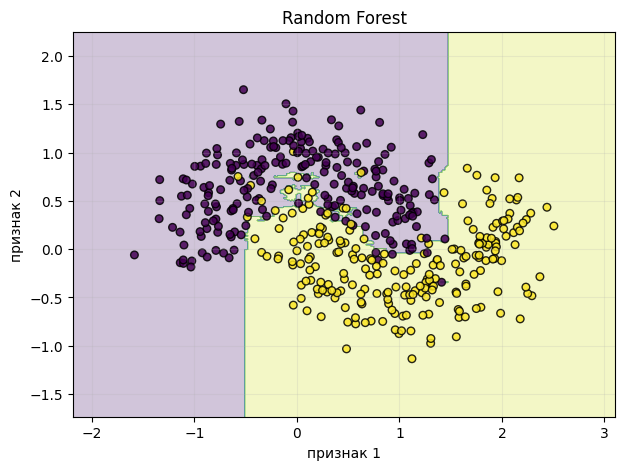

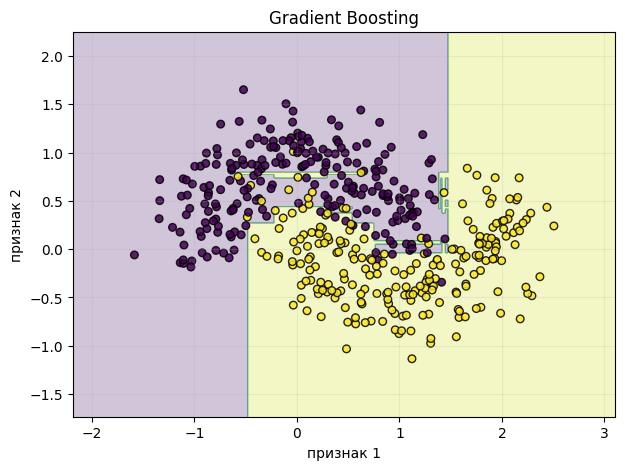

,модель,train_accuracy,test_accuracy
0,Decision Tree,1.000,0.937
1,Random Forest,1.000,0.949
2,Gradient Boosting,0.973,0.956


In [17]:

ensemble_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=None, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=120, learning_rate=0.07, max_depth=2, random_state=42),
}

rows = []
for name, model in ensemble_models.items():
    model.fit(X_train, y_train)
    rows.append({
        "модель": name,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "test_accuracy": accuracy_score(y_test, model.predict(X_test)),
    })
    plot_decision_boundary(model, X, y, name)

pd.DataFrame(rows).round(3)



## 10.1. Bagging и Random Forest: что именно снижает variance

Одиночное глубокое дерево нестабильно: небольшое изменение данных может заметно изменить структуру дерева.

**Bagging** борется с этим так:

1. Строим много bootstrap-выборок из обучающих данных.
2. На каждой выборке обучаем отдельное дерево.
3. Усредняем ответы деревьев или голосуем.

**Random Forest** добавляет ещё один источник разнообразия: в каждой вершине дерево выбирает разбиение не среди всех признаков, а среди случайного подмножества признаков.

Если ошибки отдельных деревьев не полностью совпадают, усреднение делает итоговый прогноз стабильнее.

### Out-of-bag оценка

Так как каждое дерево обучается на bootstrap-выборке, часть объектов в неё не попадает. Эти объекты можно использовать как «почти валидацию» для данного дерева. Так получается **OOB-score** — оценка качества без отдельной валидационной выборки.


In [18]:

# OOB-score у случайного леса
rf_oob = RandomForestClassifier(
    n_estimators=120,
    max_features='sqrt',
    oob_score=True,
    random_state=42,
    n_jobs=1
)
rf_oob.fit(X_train, y_train)
print(f'OOB accuracy:  {rf_oob.oob_score_:.3f}')
print(f'Test accuracy: {accuracy_score(y_test, rf_oob.predict(X_test)):.3f}')


OOB accuracy:  0.918
Test accuracy: 0.949


## 11. Learning rate и число деревьев в бустинге

В градиентном бустинге есть важный компромисс:

- маленький `learning_rate` — каждое дерево делает маленький шаг, обычно нужно больше деревьев;
- большой `learning_rate` — модель учится быстрее, но выше риск переобучения;
- `n_estimators` — число деревьев в ансамбле;
- глубина базовых деревьев обычно небольшая.

Бустинг — это не одно большое решение, а серия маленьких поправок.

In [19]:

settings = [
    (0.02, 50), (0.02, 250),
    (0.10, 50), (0.10, 250),
    (0.50, 50), (0.50, 250),
]
rows = []
for lr, n in settings:
    gb = GradientBoostingClassifier(n_estimators=n, learning_rate=lr, max_depth=2, random_state=42)
    gb.fit(X_train, y_train)
    rows.append({
        "learning_rate": lr,
        "n_estimators": n,
        "train_accuracy": accuracy_score(y_train, gb.predict(X_train)),
        "test_accuracy": accuracy_score(y_test, gb.predict(X_test)),
    })

pd.DataFrame(rows).round(3)


,learning_rate,n_estimators,train_accuracy,test_accuracy
0,0.02,50,0.911,0.930
1,0.02,250,0.935,0.930
2,0.10,50,0.935,0.924
3,0.10,250,1.000,0.956
4,0.50,50,1.000,0.949
5,0.50,250,1.000,0.943



## 11.1. Градиентный бустинг через псевдо-остатки

Бустинг строит ансамбль последовательно: каждая новая модель исправляет ошибки предыдущих.

Для регрессии с MSE это можно объяснить почти без производных:

1. Первая модель даёт грубый прогноз.
2. Считаем остатки: `y - prediction`.
3. Следующее дерево учится предсказывать эти остатки.
4. Новый прогноз = старый прогноз + маленький шаг в сторону исправления.

Для классификации идея такая же, но «остатки» считаются не как обычная разность классов, а как направление, в котором нужно уменьшить функцию потерь. Поэтому используется термин **градиент**.

Ключевые параметры:

- `n_estimators`: сколько шагов исправления делаем;
- `learning_rate`: насколько осторожно добавляем каждое новое дерево;
- `max_depth`: насколько сложным может быть каждое базовое дерево;
- `subsample`: можно обучать шаги на случайных подвыборках, добавляя стохастичность.

Бустинг часто даёт высокое качество, но чувствительнее к настройкам, чем случайный лес.


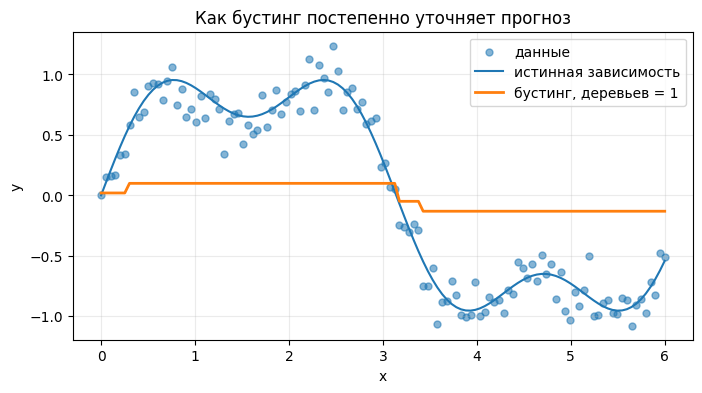

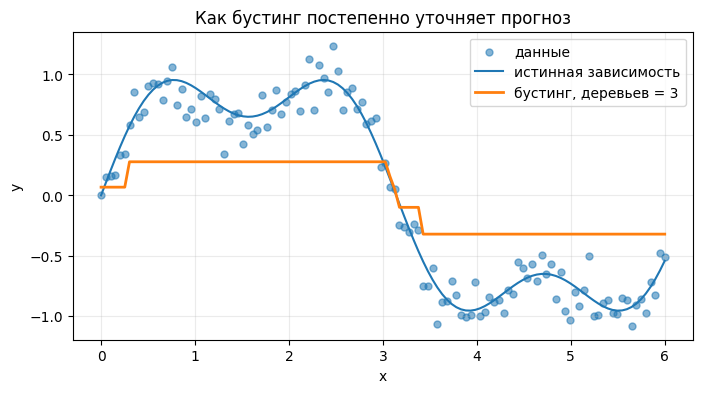

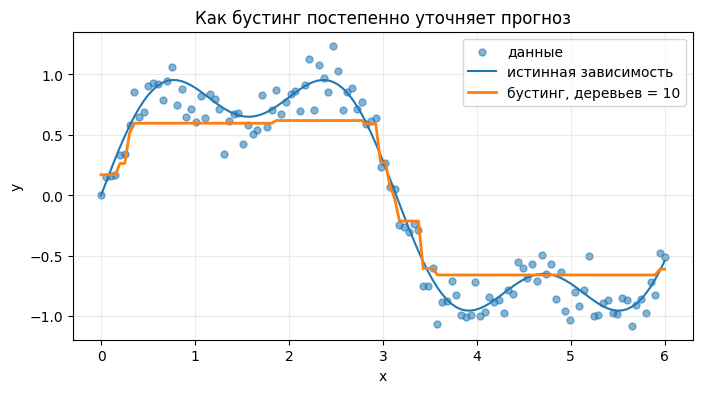

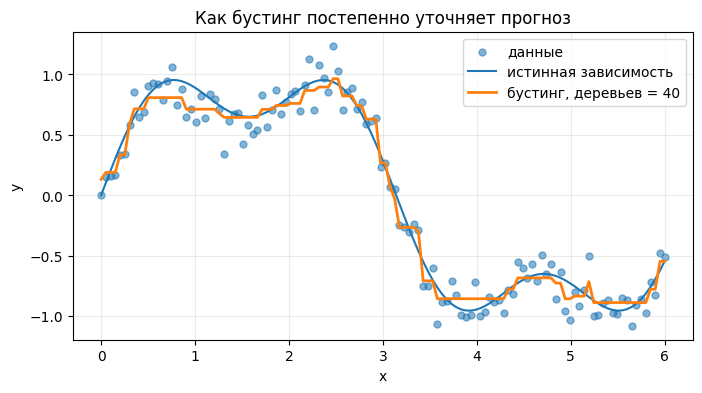

In [20]:

# Визуализация идеи бустинга на регрессии: последовательное исправление остатков
rng = np.random.default_rng(7)
x_demo = np.linspace(0, 6, 120)
y_true_demo = np.sin(x_demo) + 0.35 * np.sin(3*x_demo)
y_demo = y_true_demo + rng.normal(0, 0.15, size=x_demo.shape)
X_demo = x_demo.reshape(-1, 1)

from sklearn.ensemble import GradientBoostingRegressor

for n_estimators in [1, 3, 10, 40]:
    gbr = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=0.15,
        max_depth=2,
        random_state=42
    )
    gbr.fit(X_demo, y_demo)
    pred = gbr.predict(X_demo)
    plt.figure(figsize=(8, 4))
    plt.scatter(x_demo, y_demo, s=25, alpha=0.55, label='данные')
    plt.plot(x_demo, y_true_demo, label='истинная зависимость')
    plt.plot(x_demo, pred, linewidth=2, label=f'бустинг, деревьев = {n_estimators}')
    plt.title('Как бустинг постепенно уточняет прогноз')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
